<h1 align="center">Física Computacional.</h1>
<h1 align="center">Semestre 2027-1</h1>

<h2>Sergio A. Alcalá Corona </h2> 

---
### Rodrigo Vega Vilchis
### Joel Gómez Uribe
---

<h1 align="center">Programación para la física computacional</h1> 

## Práctica 3.  Graficacion en en Python
---
<h2>Diaz Castro Gerson Joshua </h2> 
---

### 1. Gráfica de datos experimentales

El archivo `manchasolares.txt` (adjunto), contiene el número observado de manchas solares en el Sol en cada mes desde enero de 1749. El archivo contiene dos columnas de números, la primera es el mes y la segunda el número de manchas solares.

(a) Escribe un programa que lea los datos y haga una gráfica de las manchas solares en función del tiempo.

In [1]:
#Importamos las librerias que vamos a utilizar
import numpy as np
import matplotlib.pyplot as plt

In [8]:
#abrimos el buffer y guardamos los datos en una variable
with open('manchasolares.txt','r') as ms:
    datos = ms.readlines()
    
#Ahora colocamos esos datos en un array de numpy
Adatos = np.loadtxt(datos)
Adatos

array([[0.000e+00, 5.800e+01],
       [1.000e+00, 6.260e+01],
       [2.000e+00, 7.000e+01],
       ...,
       [3.140e+03, 2.520e+01],
       [3.141e+03, 2.350e+01],
       [3.142e+03, 2.160e+01]])

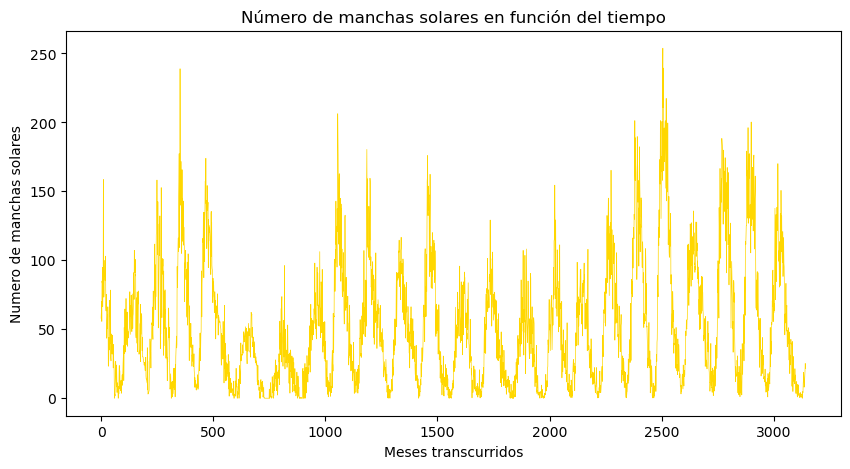

In [51]:
#Ahora graficamos nuestros datos en el eje x los meses y en el eje y las manchas
#Notese que el eje x es la columna 0 del arreglo y el eje y la columna 1
plt.figure(figsize=(10, 5))
plt.plot(Adatos[:,0],Adatos[:,1],color = "gold",linewidth=0.5)
#Personalizamos un poco nuestra grafica
plt.xlabel("Meses transcurridos")
plt.ylabel("Numero de manchas solares")
plt.title("Número de manchas solares en función del tiempo")
plt.show()

(b) Modifica tu programa para mostrar solo los primeros 1000 datos (experimentales) en la gráfica.

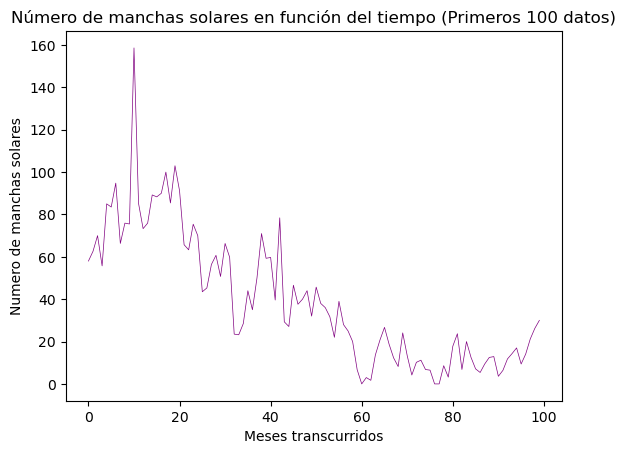

In [52]:
#Es practicamente lo mismo solo que en el arreglo delimitamos la cantidad de datos 
plt.plot(Adatos[:100,0],Adatos[:100,1],color = "purple",linewidth=0.5)
#Personalizamos un poco nuestra grafica
plt.xlabel("Meses transcurridos")
plt.ylabel("Numero de manchas solares")
plt.title("Número de manchas solares en función del tiempo (Primeros 100 datos)")
plt.show()

(c) Modifica nuevamente tu programa para calcular y graficar la *media (promedio) móvil* de los datos, definida por:

$$Y_k = \frac{1}{2r + 1} \sum_{m=-r}^{r} y_{k+m},$$

donde $r = 5$ (en este caso) y $y_k$ son los números de manchas solares.
El programa debe graficar tanto los datos originales como la *media móvil* en el mismo gráfico, sólo sobre los primeros 1000 datos.

In [35]:
#Para cada mes debo sumarle los cicno anteriores y los cinco seguidos, pero para los valores 0,1,2... del arreglo no hay 5 anteriores
#POr lo que iniciamos desde el mes 6

manchas = Adatos[:1010,1] #1010 datos para que el primero tenga 5 anteriores y el ultimo tenga 5 seguidos
Y_k = [] #Guarda los satos de la media
r = 5
k = ((2*r)+1)**(-1)

In [36]:
#Ahora hagamos un for para hacer la suma

for i in range(1000):
    media = 0 #Una variable para ir guardando la suma (se borra para cada i)
    for j in range(11):
        mancha = manchas[i+j]#actualizamos el valor de mancha con la posicion que le toca sumar
        media += mancha 
    #Multiplicamos toda la suma por k y lo guardamos en un arreglo
    y_k = k*media
    Y_k.append(y_k)
        
        
        

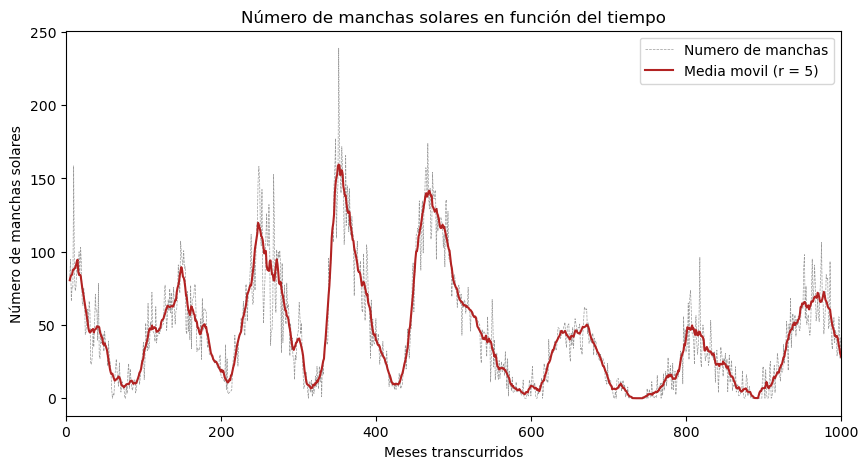

In [50]:
#Grafiquemos nuestros datos
plt.figure(figsize=(10, 5))
plt.plot(Adatos[5:1005,0],Adatos[5:1005,1],color = "black", alpha=0.4,linewidth=0.5, linestyle = "--", label = "Numero de manchas")
plt.plot(Adatos[5:1005,0],Y_k, color = "firebrick", label = "Media movil (r = 5)")
#Personalizamos un poco nuestra grafica
plt.title('Número de manchas solares en función del tiempo')
plt.xlabel('Meses transcurridos')
plt.ylabel('Número de manchas solares')
plt.xlim(0, 1000)
plt.legend()
plt.show()

### 2. La gráfica de Feigenbaum (caos determinista)

El texto introductorio aborda el concepto del *efecto mariposa* y el caos determinista, ilustrando cómo pequeñas perturbaciones en las condiciones iniciales pueden alterar drásticamente la evolución de un sistema, citando referencias que van desde la cultura pop hasta el trabajo del físico Edward Lorenz en 1972. Este fenómeno es característico de sistemas físicos complejos, como la dinámica de fluidos, donde el comportamiento es sumamente difícil de predecir.

Un modelo clásico para estudiar este fenómeno es el **mapeo logístico**, definido mediante la siguiente ecuación iterativa:

$$x_{n+1} = r x_n (1 - x_n)$$

Al iterar esta ecuación utilizando un valor constante $r$ y una condición inicial $x_n$ (por ejemplo, $x = \frac{1}{2}$), el valor resultante se vuelve a introducir en la ecuación repetidamente. Dependiendo de los parámetros, el sistema puede presentar una de las siguientes tres situaciones:

*   **Punto fijo:** El resultado converge y permanece constante en un solo número (por ejemplo, $x_n = 0$ siempre producirá $x_{n+1} = 0$).
*   **Órbita o ciclo límite:** El sistema no se asienta en un solo valor, sino que oscila de forma periódica repitiendo una secuencia específica de valores.
*   **Caos determinista:** Se genera una secuencia de números aparentemente aleatoria y sin ningún patrón evidente. Aunque los resultados parecen caóticos, están estrictamente determinados y son predecibles por la ecuación matemática inicial.

**Responde a las siguientes preguntas:**

(a) Apóyate en el programa que vimos en clase y **escribe un programa que muestre el comportamiento del mapeo logístico** mediante una gráfica.

In [54]:
import numpy as np
import matplotlib.pyplot as plt

#Definir los parametros del sistema
n_i = 1000     # Numero total de iteraciones por cada r
n_t = 900     # Primeros pasos que ignoramos para que el sistema se estabilice
r = np.linspace(2.5, 4.0, 10000)  # Rango de r (el caos es visible entre 3.5 y 4.0)

# x debe estar entre 0 y 1. Usamos un arreglo para evaluar todos los r al mismo tiempo.
x = 0.5 * np.ones(len(r)) 


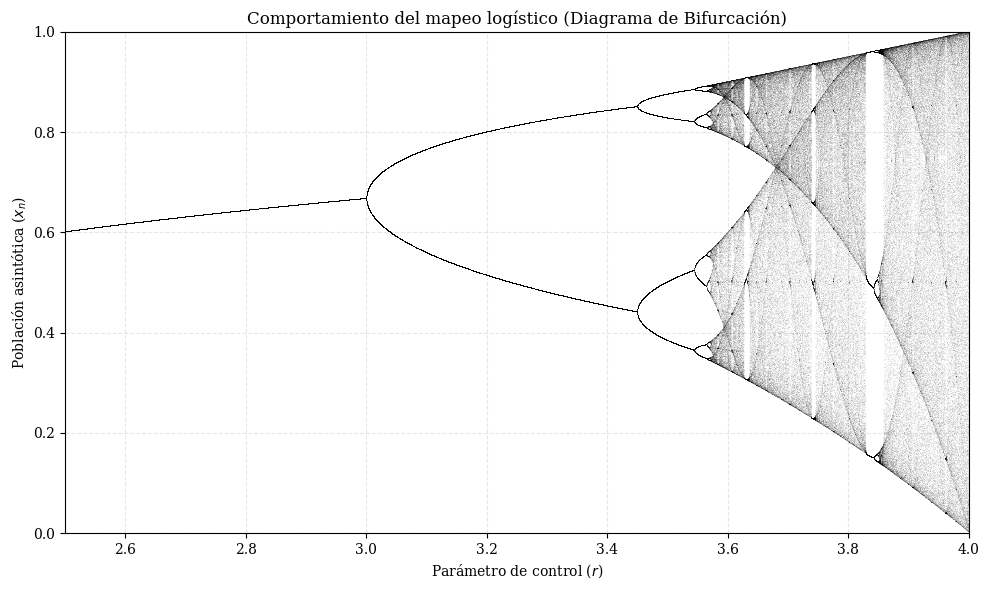

In [60]:
#lo hacemos mas grande para que se vea mejor
plt.figure(figsize=(10, 6))

#usamos el for para el bucle
for i in range(n_i):
    # La ecuacion principal
    x = r * x * (1 - x)
    
    # agora graficamos solo el régimen asintotico (después del transitorio)
    if i >= n_t:
        # Usamos ',k' para graficar pixeles negros individuales y un alpha bajo
        # para que la acumulacion de puntos oscurezca las zonas de mayor densidad
        plt.plot(r, x, ',k', alpha=0.05)

# Detalles esteticos de la grafica
plt.xlim(2.5, 4.0)
plt.ylim(0, 1)
plt.title('Comportamiento del mapeo logístico (Diagrama de Bifurcación)')
plt.xlabel('Parámetro de control ($r$)')
plt.ylabel('Población asintótica ($x_n$)')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()
        

(b) De acuerdo a tu gráfica, ¿a qué valor de $r$ el sistema pasa de un comportamiento ordenado (puntos fijos o ciclos límite) a un comportamiento caótico? A este punto a veces se le llama "el borde del caos".

De a cuerdo a la grafica podemos observar que el diagrama se vuelve caotico aproximadamente al valor de r igual a 3.5, tal como se puede observar a continuacion

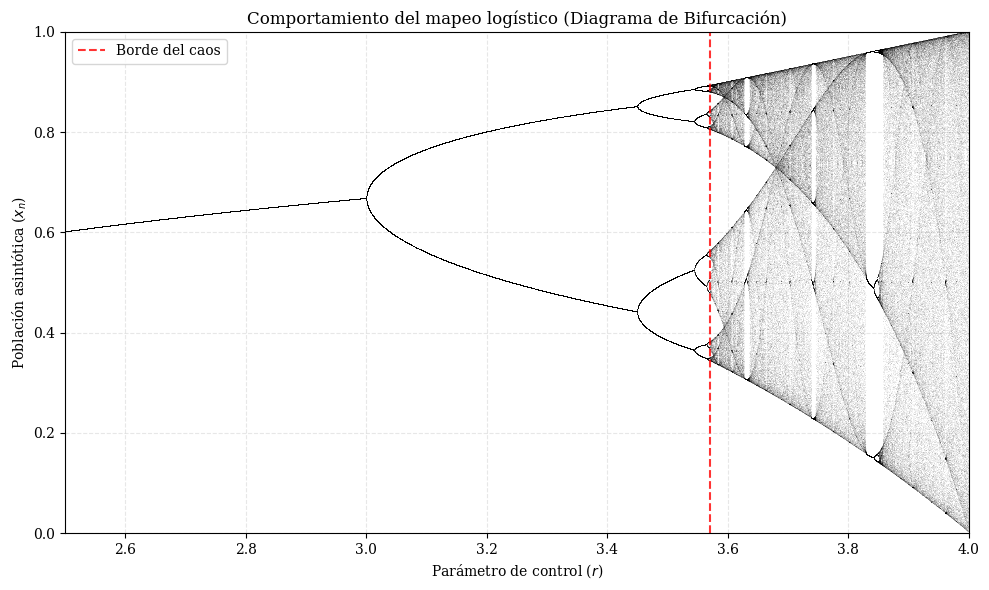

In [61]:
#lo hacemos mas grande para que se vea mejor
plt.figure(figsize=(10, 6))

#usamos el for para el bucle
for i in range(n_i):
    # La ecuacion principal
    x = r * x * (1 - x)
    
    # agora graficamos solo el régimen asintotico (después del transitorio)
    if i >= n_t:
        # Usamos ',k' para graficar pixeles negros individuales y un alpha bajo
        # para que la acumulacion de puntos oscurezca las zonas de mayor densidad
        plt.plot(r, x, ',k', alpha=0.05)

# Detalles esteticos de la grafica
plt.xlim(2.5, 4.0)
plt.ylim(0, 1)
plt.title('Comportamiento del mapeo logístico (Diagrama de Bifurcación)')
plt.xlabel('Parámetro de control ($r$)')
plt.ylabel('Población asintótica ($x_n$)')
plt.axvline(x=3.57, color='red', linestyle='--', alpha=0.8, label='Borde del caos')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.legend()
plt.show()
        

### 3. El conjunto de Mandelbrot

El conjunto de Mandelbrot, nombrado en honor al matemático francés Benoît Mandelbrot, es un *fractal*; un objeto matemático infinitamente ramificado que contiene estructura dentro de estructura, sin importar qué tan profundo observemos. Su definición en términos de números complejos parte de la siguiente ecuación:

$$z_{n+1} = z_n^2 + c, \quad z_n, c \in \mathbb{C}$$

donde $z_n$ es un número complejo y $c$ es una constante compleja. Al igual que en el mapeo logístico, la definición implica iterar repetidamente esta ecuación para un valor dado de $c$, tomando una condición inicial $z_0$ para obtener $z_1$, luego usar ese resultado para obtener $z_2$, y así sucesivamente.

El conjunto de Mandelbrot se define como el conjunto de puntos en el plano complejo que cumple con la siguiente condición:

> *Para un valor dado de $c$ y la condición inicial $z_0 = 0$; si al iterar repetidamente la ecuación, la magnitud del valor resultante es mayor a dos (es decir, $|z_\infty| > 2$), entonces el punto del plano complejo para ese valor $c$ no pertenece al conjunto de Mandelbrot; de lo contrario, sí pertenece*.

En principio, se requerirían infinitas iteraciones para comprobar rigurososamente que un punto pertenece al conjunto (verificando que la magnitud $|z_n|$ nunca supere 2). Sin embargo, en la práctica computacional, basta con realizar un número grande de iteraciones (por ejemplo, 100); si después de este proceso $|z_n|$ no ha excedido 2, se asume que la aproximación es suficientemente buena y el punto está dentro del conjunto.

**(a) Escribe un programa para crear una imagen del conjunto de Mandelbrot** realizando la iteración para todos los valores de $c = x + iy$ en una cuadrícula de $N \times N$ que abarque la región donde $-2 \leq x \leq 2$ y $-2 \leq y \leq 2$. Haz una gráfica de densidad (*density plot*) en la que los puntos de la cuadrícula que pertenecen al conjunto de Mandelbrot estén coloreados de negro, y los que están fuera aparezcan en blanco.

*Sugerencia:* Probablemente te resulte útil comenzar con una cuadrícula muy simple, utilizando un valor pequeño de $N$ (quizás $N = 100$) para que tu programa se ejecute rápido durante las pruebas. Una vez que te asegures de que funciona correctamente, puedes aumentar el valor de $N$ para producir una imagen final de alta calidad.

In [71]:
import numpy as np
import matplotlib.pyplot as plt

# Resolucion de la cuadrícula (N x N)
N = 1000 

# Definimos los ejes real e imaginario entre -2 y 2
x = np.linspace(-2, 2, N)
y = np.linspace(-2, 2, N)

# meshgrid crea matrices 2D a partir de los vectores 1D para evaluar toda la cuadricula a la vez
X, Y = np.meshgrid(x, y)

# Creamos el plano complejo
C = X + 1j * Y

# ahora aploicamos la condicion inicial Z_0
Z = np.zeros_like(C)


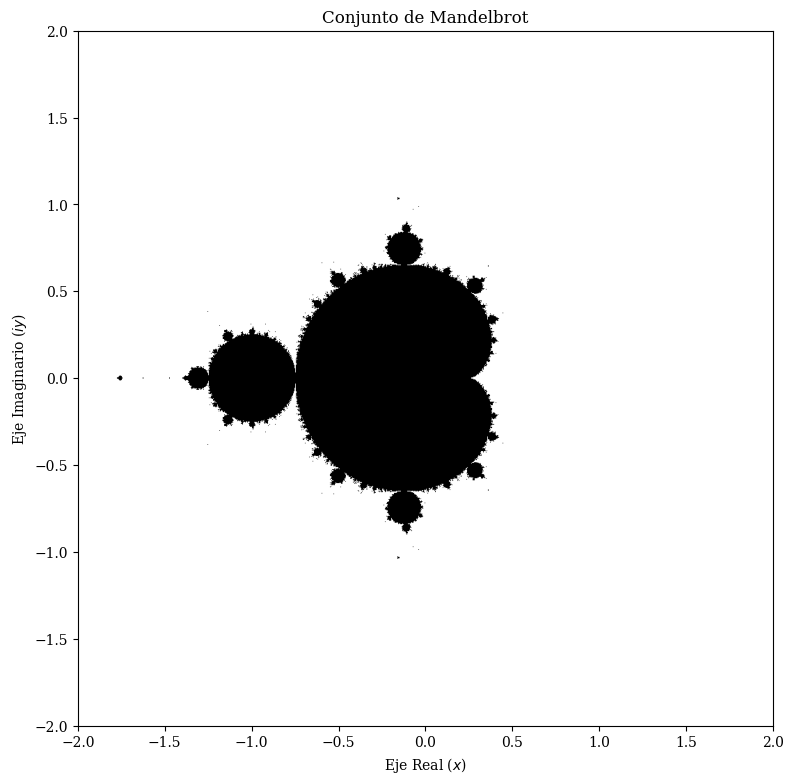

In [72]:
# Matriz booleana para registrar qué puntos pertenecen al conjunto
# Asumimos que todos pertenecen (True) hasta que su magnitud supere 2
m = np.ones(C.shape, dtype=bool)

# Bucle de 100 iteraciones
for _ in range(100):
    # Iteramos únicamente los puntos que siguen dentro de la condición (mandelbrot == True)
    Z[m] = Z[m]**2 + C[m]
    
    # Si la magnitud supera 2, el punto escapa y se actualiza a False
    m[m] = np.abs(Z[m]) <= 2

# Configuración del lienzo y tipografía
plt.figure(figsize=(8, 8))
plt.imshow(m, extent=[-2, 2, -2, 2], cmap='binary', origin='lower')

plt.title('Conjunto de Mandelbrot')
plt.xlabel('Eje Real ($x$)')
plt.ylabel('Eje Imaginario ($iy$)')

plt.tight_layout()
plt.show()